In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ruhulaminsharif/eye-disease-image-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/eye-disease-image-dataset


In [10]:
from pathlib import Path

data_path = Path(path)
print("Subfolders:", [p.name for p in data_path.iterdir() if p.is_dir()])


Subfolders: ['Original Dataset', 'Augmented Dataset']


In [11]:
import os
import shutil
import random
from pathlib import Path

# Set the correct base path
source_base = Path("/kaggle/input/eye-disease-image-dataset/Original Dataset/Original Dataset")
selected_classes = ["Myopia", "Healthy"]

# Destination for YOLOv8 formatted dataset
target_base = Path("/kaggle/working/myopia_dataset")
train_dir = target_base / "train"
val_dir = target_base / "val"

# Create train/val folders
for cls in selected_classes:
    os.makedirs(train_dir / cls, exist_ok=True)
    os.makedirs(val_dir / cls, exist_ok=True)

# Split ratio
split_ratio = 0.8

# Copy and split images
for cls in selected_classes:
    images = list((source_base / cls).glob("*"))
    random.shuffle(images)
    split_idx = int(len(images) * split_ratio)
    
    for img in images[:split_idx]:
        shutil.copy(img, train_dir / cls / img.name)
    for img in images[split_idx:]:
        shutil.copy(img, val_dir / cls / img.name)

print("✅ Dataset prepared for YOLOv8 classification.")
print("Train samples:", sum(len(list((train_dir / cls).glob('*'))) for cls in selected_classes))
print("Val samples:", sum(len(list((val_dir / cls).glob('*'))) for cls in selected_classes))


✅ Dataset prepared for YOLOv8 classification.
Train samples: 1219
Val samples: 305


In [12]:
import os
import shutil
import random
from pathlib import Path

def prepare_yolo_cls_dataset(
    source_root: Path,
    class_names: list,
    dest_root: Path,
    split_ratio: float = 0.8,
    image_extensions: tuple = ('.jpg', '.jpeg', '.png')
):
    # Ensure destination folders exist
    train_dir = dest_root / "train"
    val_dir = dest_root / "val"
    for cls in class_names:
        os.makedirs(train_dir / cls, exist_ok=True)
        os.makedirs(val_dir / cls, exist_ok=True)

    print(f"📁 Preparing dataset from: {source_root}")
    print(f"✅ Classes selected: {class_names}")
    print(f"📦 Output directory: {dest_root}")

    # Process each class
    for cls in class_names:
        src_cls_dir = source_root / cls
        if not src_cls_dir.exists():
            print(f"⚠️ Warning: Source folder '{src_cls_dir}' does not exist. Skipping...")
            continue

        # Collect images with supported extensions
        images = [img for ext in image_extensions for img in src_cls_dir.glob(f"*{ext}")]
        random.shuffle(images)

        if len(images) == 0:
            print(f"⚠️ No images found in class '{cls}'")
            continue

        # Split and copy
        split_idx = int(len(images) * split_ratio)
        for img in images[:split_idx]:
            shutil.copy(img, train_dir / cls / img.name)
        for img in images[split_idx:]:
            shutil.copy(img, val_dir / cls / img.name)

        print(f"✔️ {cls}: {len(images[:split_idx])} train, {len(images[split_idx:])} val")

    print("\n🎉 Dataset preparation completed!")
    return train_dir, val_dir


# === USAGE ===
source_path = Path("/kaggle/input/eye-disease-image-dataset/Original Dataset/Original Dataset")
target_path = Path("/kaggle/working/myopia_dataset")
classes_to_include = ["Myopia", "Healthy"]

prepare_yolo_cls_dataset(source_path, classes_to_include, target_path)


📁 Preparing dataset from: /kaggle/input/eye-disease-image-dataset/Original Dataset/Original Dataset
✅ Classes selected: ['Myopia', 'Healthy']
📦 Output directory: /kaggle/working/myopia_dataset
✔️ Myopia: 400 train, 100 val
✔️ Healthy: 819 train, 205 val

🎉 Dataset preparation completed!


(PosixPath('/kaggle/working/myopia_dataset/train'),
 PosixPath('/kaggle/working/myopia_dataset/val'))

In [14]:
!pip install -q ultralytics

from ultralytics import YOLO

model = YOLO("yolov8n-cls.pt")  # or yolov8s-cls.pt
model.train(data=str(target_path), epochs=10, imgsz=224)


Ultralytics 8.3.107 🚀 Python-3.11.11 torch-2.5.1+cu124 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=classify, mode=train, model=yolov8n-cls.pt, data=/kaggle/working/myopia_dataset, epochs=10, time=None, patience=100, batch=16, imgsz=224, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, lin

train: Scanning /kaggle/working/myopia_dataset/train... 1453 images, 0 corrupt: 100%|██████████| 1453/1453 [00:00<?, ?it/s]
val: Scanning /kaggle/working/myopia_dataset/val... 539 images, 0 corrupt: 100%|██████████| 539/539 [00:00<?, ?it/s]

optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001667, momentum=0.9) with parameter groups 26 weight(decay=0.0), 27 weight(decay=0.0005), 27 bias(decay=0.0)


TensorBoard: model graph visualization added ✅
Image sizes 224 train, 224 val
Using 0 dataloader workers
Logging results to runs/classify/train2
Starting training for 10 epochs...

      Epoch    GPU_mem       loss  Instances       Size


               classes   top1_acc   top5_acc: 100%|██████████| 17/17 [00:31<00:00,  1.84s/it]

...

                   all      0.963          1

10 epochs completed in 0.396 hours.
Optimizer stripped from runs/classify/train2/weights/last.pt, 3.0MB


Optimizer stripped from runs/classify/train2/weights/best.pt, 3.0MB

Validating runs/classify/train2/weights/best.pt...
Ultralytics 8.3.107 🚀 Python-3.11.11 torch-2.5.1+cu124 CPU (Intel Xeon 2.20GHz)
YOLOv8n-cls summary (fused): 30 layers, 1,437,442 parameters, 0 gradients, 3.3 GFLOPs
train: /kaggle/working/myopia_dataset/train... found 1453 images in 2 classes ✅ 
val: /kaggle/working/myopia_dataset/val... found 539 images in 2 classes ✅ 
test: None...


               classes   top1_acc   top5_acc: 100%|██████████| 17/17 [00:31<00:00,  1.84s/it]


                   all      0.972          1
Speed: 0.0ms preprocess, 10.9ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/train2


ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79ff4d178250>
curves: []
curves_results: []
fitness: 0.9860853552818298
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9721707105636597, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9860853552818298}
save_dir: PosixPath('runs/classify/train2')
speed: {'preprocess': 0.0009441614067955167, 'inference': 10.858861840445845, 'loss': 5.8495360748150775e-05, 'postprocess': 0.0001596623373870476}
task: 'classify'
top1: 0.9721707105636597
top5: 1.0

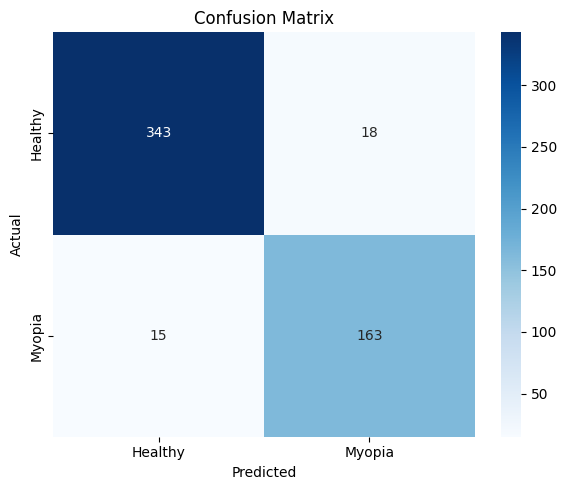

In [17]:
import os
import numpy as np
from pathlib import Path
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from ultralytics import YOLO
from PIL import Image

# === Paths ===
val_dir = Path("/kaggle/working/myopia_dataset/val")
class_names = ["Healthy", "Myopia"]  # Ensure order matches the YOLO class index
class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}

# === Load Trained Model ===
model = YOLO("runs/classify/train/weights/best.pt")  # path to your trained model

# === Gather Ground Truth and Predictions ===
y_true = []
y_pred = []

for cls in class_names:
    cls_folder = val_dir / cls
    for img_path in cls_folder.glob("*"):
        img = Image.open(img_path).convert("RGB")
        pred = model.predict(img, imgsz=224, verbose=False)
        
        predicted_class_idx = int(pred[0].probs.top1)
        y_pred.append(predicted_class_idx)
        y_true.append(class_to_idx[cls])

# === Compute and Plot Confusion Matrix ===
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [2]:
!pip install scikit-learn seaborn


In [5]:
class_names = ["Myopia", "Healthy"]


🔍 Classification Report:
              precision    recall  f1-score   support

     Healthy     0.9581    0.9501    0.9541       361
      Myopia     0.9006    0.9157    0.9081       178

    accuracy                         0.9388       539
   macro avg     0.9293    0.9329    0.9311       539
weighted avg     0.9391    0.9388    0.9389       539


✅ Overall Accuracy: 0.9388


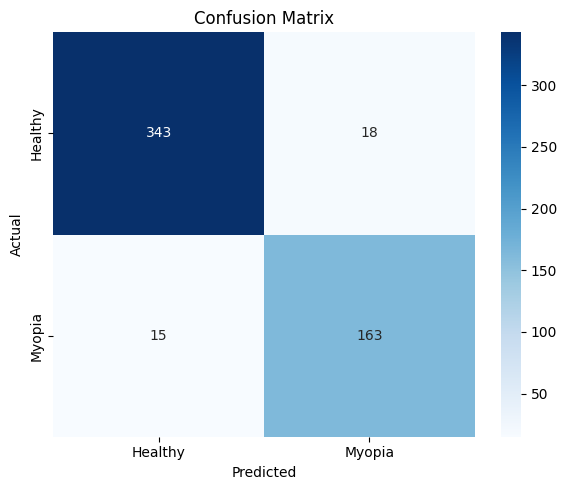

In [18]:
import os
import numpy as np
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from ultralytics import YOLO
from PIL import Image

# === Paths ===
val_dir = Path("/kaggle/working/myopia_dataset/val")
class_names = ["Healthy", "Myopia"]  # Make sure this matches your training class order
class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}

# === Load Trained Model ===
model = YOLO("runs/classify/train/weights/best.pt")  # path to your trained model

# === Gather Ground Truth and Predictions ===
y_true = []
y_pred = []

for cls in class_names:
    cls_folder = val_dir / cls
    for img_path in cls_folder.glob("*"):
        img = Image.open(img_path).convert("RGB")
        pred = model.predict(img, imgsz=224, verbose=False)
        
        predicted_class_idx = int(pred[0].probs.top1)
        y_pred.append(predicted_class_idx)
        y_true.append(class_to_idx[cls])

# === Accuracy and Metrics ===
print("🔍 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# === Optional: Print Accuracy separately ===
acc = accuracy_score(y_true, y_pred)
print(f"\n✅ Overall Accuracy: {acc:.4f}")

# === Confusion Matrix Plot ===
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [20]:
import torch
import torchvision.transforms as transforms
from PIL import Image
from pathlib import Path
from ultralytics import YOLO
import numpy as np
import os

# === Load Model ===
model = YOLO("runs/classify/train/weights/best.pt")  # Trained classification model
backbone = model.model.model[:-1]  # Exclude the classification head

# === Image Transformations ===
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# === Feature Extraction Function ===
def extract_features(img_path):
    img = Image.open(img_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0)  # Add batch dimension
    with torch.no_grad():
        features = backbone(input_tensor)[0]
    return features.flatten().numpy()  # You can return raw tensor if preferred

# === Extract Features for Validation Set ===
val_dir = Path("/kaggle/working/myopia_dataset/val")
class_names = ["Healthy", "Myopia"]
feature_list = []
label_list = []

for label, cls in enumerate(class_names):
    cls_folder = val_dir / cls
    for img_path in cls_folder.glob("*"):
        feat = extract_features(img_path)
        feature_list.append(feat)
        label_list.append(label)

# === Convert to Arrays ===
X = np.array(feature_list)  # Features
y = np.array(label_list)    # Labels

print("✅ Feature extraction completed.")
print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")


✅ Feature extraction completed.
Features shape: (539, 12544)
Labels shape: (539,)


In [3]:
!pip install -q timm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.4 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 28.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 11.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 68.9 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pylibcugraph-cu12 24.12.0 requires pylibraft-cu12==24.12.*, but you have pylibraft-cu12 25.2.0 which is incompatible.
pylibcugraph-cu12 24.12.0 requires rmm-cu12==24.12.*, but you have 

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm  # for pretrained CoAtNet
import os


In [23]:
# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# Load datasets from prepared folders
data_dir = "/kaggle/working/myopia_dataset"
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
print("Classes:", class_names)


Classes: ['Healthy', 'Myopia']


In [5]:
# Load CoAtNet from timm
model = timm.create_model("coatnet_0_rw_224.sw_in1k", pretrained=True)

# Modify classifier to match 2 classes (Myopia, Healthy)
model.head = nn.Linear(model.head.in_features, 2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


model.safetensors:   0%|          | 0.00/110M [00:00<?, ?B/s]

MaxxVit(
  (stem): Stem(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (norm1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  )
  (stages): Sequential(
    (0): MaxxVitStage(
      (blocks): Sequential(
        (0): MbConvBlock(
          (shortcut): Downsample2d(
            (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
            (expand): Conv2d(64, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          )
          (pre_norm): BatchNormAct2d(
            64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (down): Downsample2d(
            (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
            (expand): Identity

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [7]:
import timm
import torch.nn as nn
import torch

# Load pretrained CoAtNet
model = timm.create_model("coatnet_0_rw_224.sw_in1k", pretrained=True)

# Check if pooling is missing before classification
# Add AdaptiveAvgPool and Flatten manually (CoAtNet sometimes returns spatial features)

model.head = nn.Sequential(
    nn.AdaptiveAvgPool2d((1, 1)),  # Collapse spatial dims
    nn.Flatten(),                  # (B, C, 1, 1) -> (B, C)
    nn.Linear(model.num_features, 2)  # Final classifier
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


MaxxVit(
  (stem): Stem(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (norm1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  )
  (stages): Sequential(
    (0): MaxxVitStage(
      (blocks): Sequential(
        (0): MbConvBlock(
          (shortcut): Downsample2d(
            (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
            (expand): Conv2d(64, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          )
          (pre_norm): BatchNormAct2d(
            64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (down): Downsample2d(
            (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
            (expand): Identity

In [29]:
dummy_input = torch.randn(4, 3, 224, 224).to(device)
output = model(dummy_input)
print(output.shape)  # Should be [4, 2]


torch.Size([4, 2])
